# SILVA Dynamic Economic Equilibrium

Represent feasible policy functions directly and train them from Euler and resource residuals without requiring labeled optimal policies. This lab adapts the cited mechanism into explicit SILVA
components [[112]], runs a deterministic compact check, and separates
that evidence from a source-scale reproduction claim.

[Download this notebook](https://github.com/jseluis/silva-networks/raw/main/notebooks/package_api/74_silva_dynamic_economic_equilibrium.ipynb)

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[112]](https://jseluis.github.io/silva-networks/paper/references/#ref-112). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import sys

root = Path.cwd()
while root != root.parent and not (root / "src" / "silva_networks").exists():
    root = root.parent
if not (root / "src" / "silva_networks").exists():
    root = Path("/content/silva-networks")
sys.path.insert(0, str(root / "src"))

import matplotlib.pyplot as plt
import torch
from torch import nn
from silva_networks import SolverConfig, silva_family_experiment_protocol

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(121)

config = SolverConfig(
    solver="picard",
    max_iter=30,
    tol=1e-6,
    backward_mode="unrolled",
    anderson_batch_dims=1,
    return_best=True,
)

## 1. Mechanism and Derivation


For capital $k$ and productivity $z$, available resources are

$$r(k,z)=e^z k^\alpha+(1-\delta)k.$$

Softmax policy shares guarantee feasibility,

$$c=s_c r,\qquad k'=s_k r,\qquad s_c+s_k=1.$$

The Euler residual for CRRA utility is

$$
\mathcal R_E=c^{-\gamma}-\beta(c')^{-\gamma}
\left[\alpha e^{z'}(k')^{\alpha-1}+1-\delta\right].
$$

Training minimizes sampled resource and Euler residuals. This family solves an economic equilibrium-function approximation; it is not a hidden-state root solve, and the distinction is explicit in the API.

## 2. SILVA State and Shape Contract

States: `(batch, state_dim)` with capital first and log productivity second. The result returns consumption, next capital, resource residual, and Euler residual, each `(batch,)`.

The transition remains a named callable, the numerical method is selected by
`SolverConfig`, and the result exposes both the solved state and solver record.
This makes architecture equivalence, numerical equivalence, and task quality
three separate questions.

In [2]:
from silva_networks import SILVADynamicEconomicEquilibrium

capital = torch.linspace(0.3, 3.0, 80)
productivity = torch.zeros_like(capital)
states = torch.stack([capital, productivity], dim=-1).requires_grad_()
model = SILVADynamicEconomicEquilibrium(state_dim=2, hidden_dim=32)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-2)
loss_curve = []
for _ in range(60):
    optimizer.zero_grad()
    trained = model(states)
    loss = trained.euler_residual.square().mean() + 10 * trained.resource_residual.square().mean()
    loss.backward()
    optimizer.step()
    loss_curve.append(float(loss.detach()))
result = model(states)
summary = {
    "maximum_resource_error": float(result.resource_residual.abs().max().detach()),
    "euler_rmse": float(result.euler_residual.square().mean().sqrt().detach()),
    "minimum_consumption": float(result.consumption.min().detach()),
    "minimum_next_capital": float(result.next_capital.min().detach()),
    "final_compact_loss": loss_curve[-1],
}
summary

{'maximum_resource_error': 4.76837158203125e-07,
 'euler_rmse': 0.02951202355325222,
 'minimum_consumption': 0.4335351288318634,
 'minimum_next_capital': 0.490746408700943,
 'final_compact_loss': 0.000912981282453984}

## 3. Read the Compact Evidence

The preceding output is a measured contract check: shapes, constraints,
residuals, and gradients were produced by this notebook. It does not imply
that the cited source benchmark has been reproduced. The figure below makes
one family-specific state or diagnostic visible.

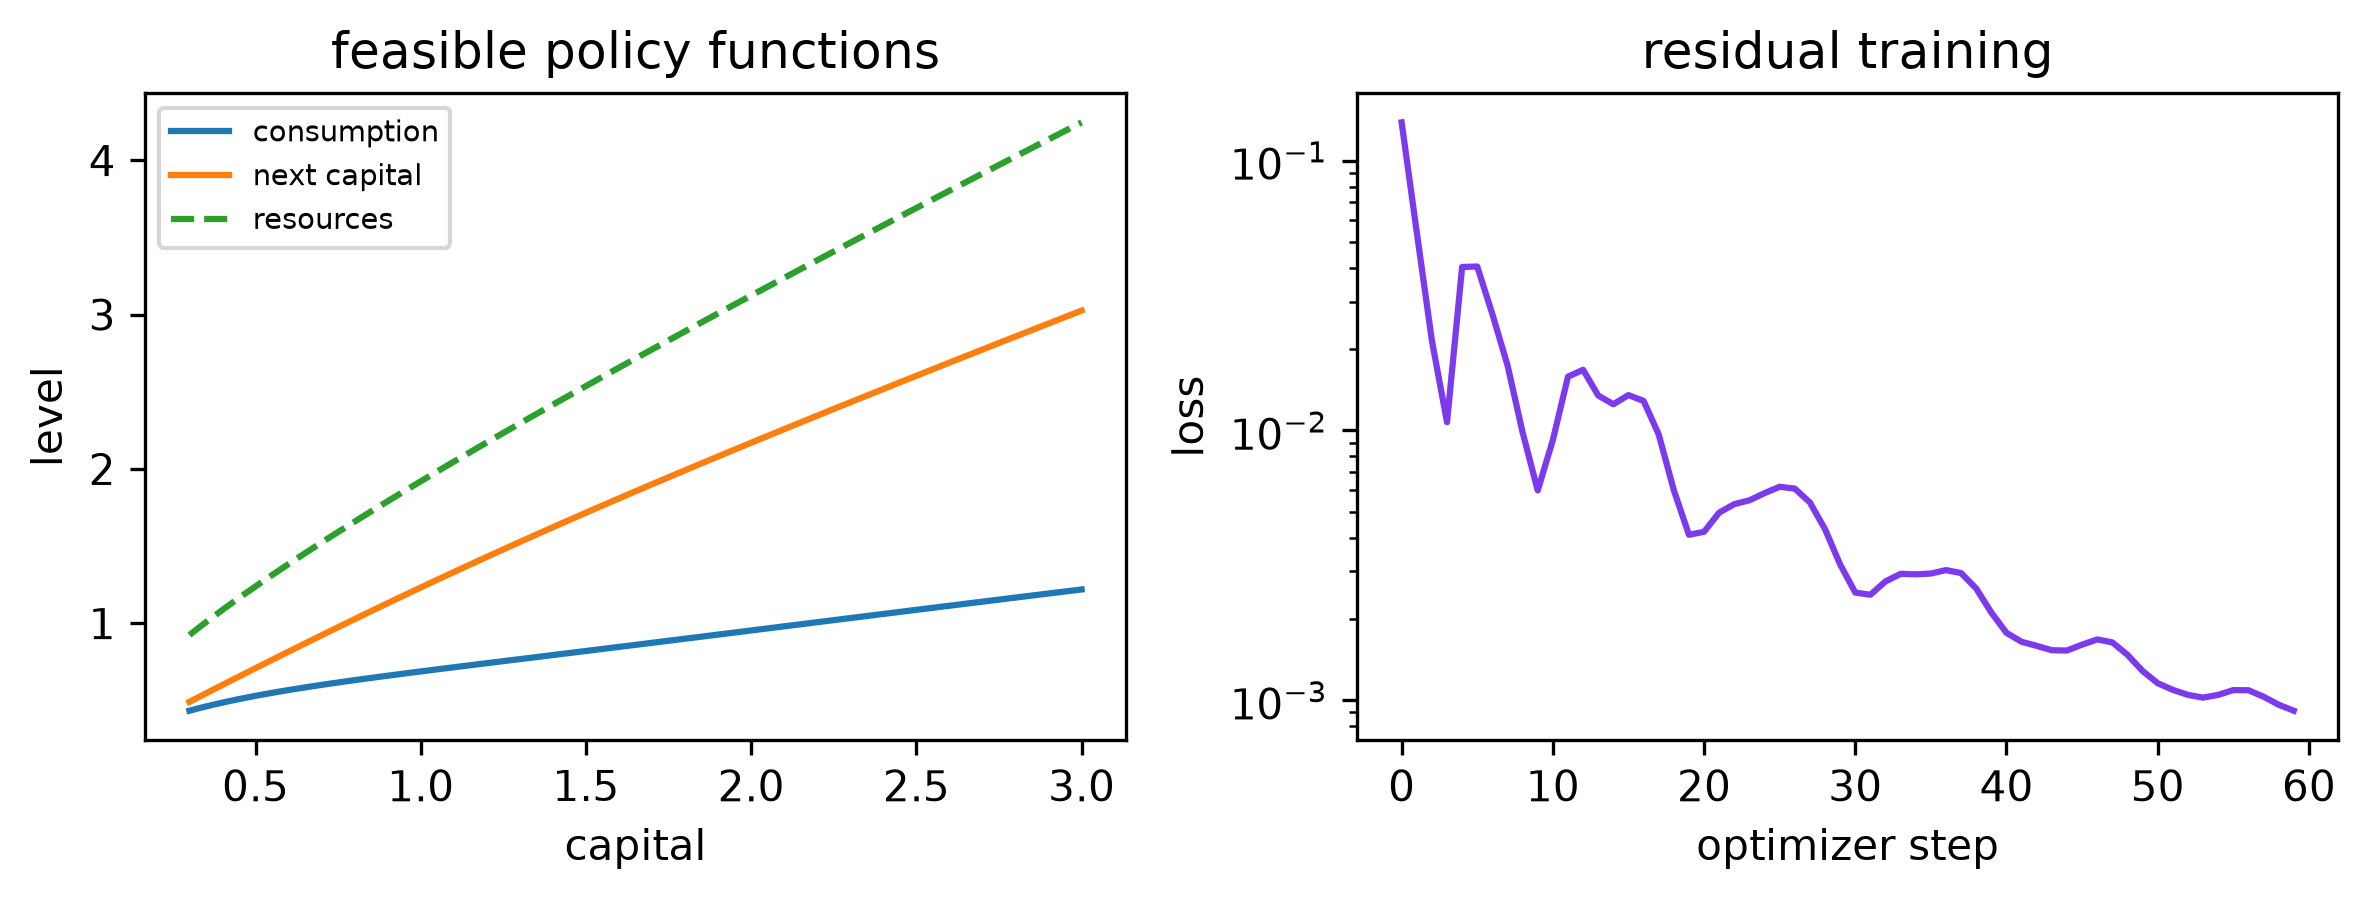

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.1))
axes[0].plot(capital, result.consumption.detach(), label="consumption")
axes[0].plot(capital, result.next_capital.detach(), label="next capital")
axes[0].plot(capital, model.resources(states).detach(), linestyle="--", label="resources")
axes[0].set(title="feasible policy functions", xlabel="capital", ylabel="level")
axes[0].legend(fontsize=7)
axes[1].semilogy(loss_curve, color="#7c3aed")
axes[1].set(title="residual training", xlabel="optimizer step", ylabel="loss")
fig.tight_layout()
plt.show()

## 4. Inspect and Replace the Internals

Replace `policy` with wider, recurrent, sparse-grid, mixture, or domain-constrained policy maps. Extend `resources`, transition laws, and residuals in a subclass for multiple agents, assets, shocks, or equilibrium conditions.

The following inventory is deliberately mechanical: an advanced experiment
can replace a child module without changing the solver or reporting contract.

In [4]:
print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
for name, child in model.named_children():
    print(f"{name:24s} -> {child.__class__.__name__}")

trainable parameters: 162
policy                   -> Sequential


## 5. Compact, Workstation, and Source Scale

Full economic reproduction requires the article's model calibration, shock process and quadrature, simulation state distribution, residual weighting, optimization schedule, test grids, Euler-error convention, and economic welfare comparisons. Report feasibility and extrapolation separately.

SILVA stores all three execution routes in the family protocol. Resource
figures are planning ranges; measured hardware, runtime, peak memory, data
revision, split, seed, and deviations belong in the completed result record.

In [5]:
protocol = silva_family_experiment_protocol("silva_dynamic_economic_equilibrium")
for tier in protocol.tiers:
    print(f"{tier.tier:11s} | {tier.dataset.name} | {tier.dataset.expected_storage}")
    print("  source:", tier.dataset.source_url)
    print("  split: ", tier.dataset.split)
    print("  run:   ", tier.command)

smoke       | generated stochastic-growth states | less than 100 MB
  source: generated://silva/economic-equilibrium
  split:  fixed parameter grid, shocks, and seed
  run:    python experiments/reproduction/run_family_protocol.py --family silva_dynamic_economic_equilibrium --tier smoke --work-dir runs/silva_dynamic_economic_equilibrium/smoke
workstation | source-model simulated path subset | 1-50 GB
  source: https://github.com/sischei/DeepEquilibriumNets
  split:  recorded model, calibration, paths, and state subsample
  run:    python experiments/reproduction/run_family_protocol.py --family silva_dynamic_economic_equilibrium --tier workstation --work-dir runs/silva_dynamic_economic_equilibrium/workstation
full        | article life-cycle and heterogeneous-agent simulations | 50 GB to 1 TB with simulated paths and checkpoints
  source: https://github.com/sischei/DeepEquilibriumNets
  split:  source equations, calibration, simulation, quadrature, and residual metrics
  run:    python 

## 6. Reproduction Checklist

Before labeling a result as source-scale reproduced, preserve the cited
equation and architecture choices, use the declared source data and split,
match preprocessing and evaluation, run the required seeds, and report task
metrics beside equilibrium residuals, iterations, failures, runtime, and peak
memory. Compact and subset runs remain valuable, but keep their evidence level
explicit.

## 7. Build the Next Variant

1. Replace one named component and keep its tensor contract fixed.
2. Verify the transition on a deterministic fixture before solving it.
3. Compare finite iteration and converged outputs at the same weights.
4. Add a task loss only after constraints, invariances, and gradients pass.
5. Scale the data and architecture independently so the cause of each change is visible.
6. Record the exact source relation: reproduced, adapted, or newly extended.

## From 74 Silva Dynamic Economic Equilibrium to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [6]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [7]:
notebook_reproduction_record = {
    "notebook": '74_silva_dynamic_economic_equilibrium.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '74_silva_dynamic_economic_equilibrium.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **transition feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the tensor solved to equilibrium**, and its repeated map,
**the state-preserving transition evaluated by the root solver**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [8]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('transition feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


transition feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


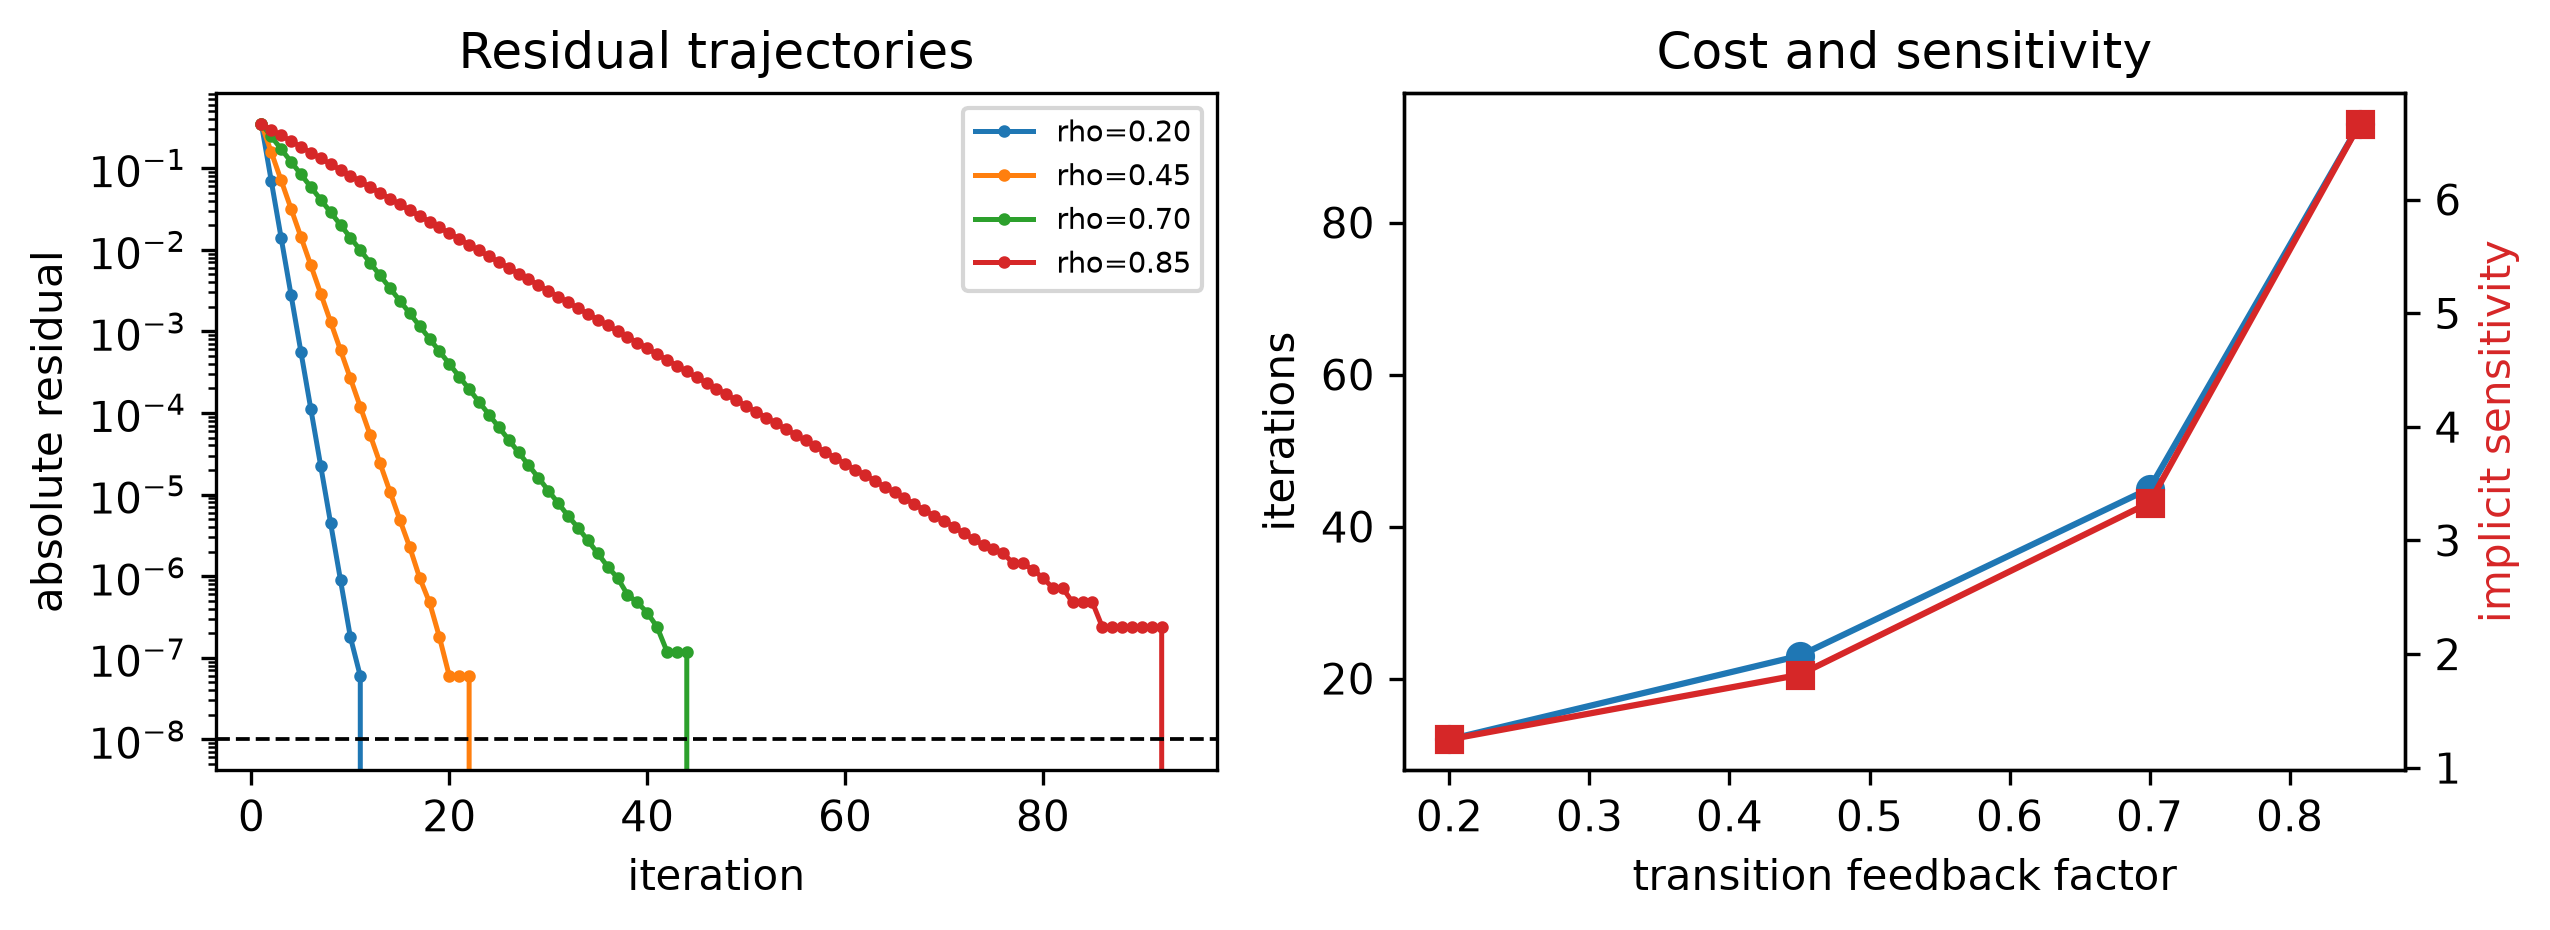

In [9]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('transition feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the transition feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | fixed-point residual and task error against a deterministic target |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | shape, device, dtype, finiteness, and differentiability |
| Scale sweep | Change one of state width, batch size, and data volume at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How are all source-aligned mechanisms derived? | [Source-Aligned Equilibrium Families](https://jseluis.github.io/silva-networks/learn/source-equilibrium-families/) |
| Which source-aligned classes and results are public? | [Source-Aligned Equilibria API](https://jseluis.github.io/silva-networks/api/source_equilibria/) |
| Where are the complete data and scale routes? | [Family Reproduction Dossiers](https://jseluis.github.io/silva-networks/families/) |
